LANGKAH 1: Membaca file Biner GGMplus...
✅ Total data: 6250000 titik. Dimensi matriks: 2500 x 2500
LANGKAH 2: Memotong data sesuai area Tampomas...
------------------------------
✅ STATISTIK DATA TAMPOMAS:
Jumlah titik : 90000
Min mGal     : 112.20
Max mGal     : 315.80
------------------------------
✅ File berhasil disimpan di: /content/tampomas_abs_final.nc


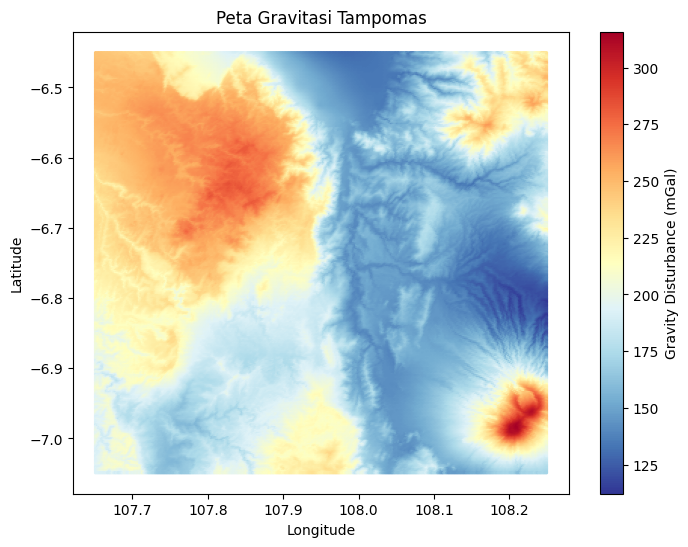

In [ ]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt

file_dg = "/content/S10E105.dg"

# Koordinat Area Proyek Tampomas
lat_min_target, lat_max_target = -7.05, -6.45
lon_min_target, lon_max_target = 107.65, 108.25

print("LANGKAH 1: Membaca file Biner GGMplus...")
if not os.path.exists(file_dg):
    print(f"❌ File {file_dg} tidak ditemukan!")
else:
    try:
        # PERBAIKAN FATAL: GGMplus .dg menggunakan format Integer 16-bit (2-byte)
        # Standar datanya adalah Big-Endian ('>i2')
        data_1d = np.fromfile(file_dg, dtype='>i2')

        n_points = len(data_1d)
        n_side = int(np.sqrt(n_points))

        # Sekarang pasti jumlahnya 6.250.000 titik, dan n_side adalah 2500
        print(f"✅ Total data: {n_points} titik. Dimensi matriks: {n_side} x {n_side}")

        # KONVERSI KE mGal:
        # Dokumentasi GGMplus menyatakan nilai integer harus dikali 0.1
        data_mgal = data_1d.astype(float) * 0.1

        # FILTER DATA KOSONG:
        # GGMplus memakai angka -32768 (-2^15) untuk area tanpa data
        data_mgal[data_mgal < -3000] = np.nan

        # Reshape menjadi matriks 2D
        data_2d = data_mgal.reshape((n_side, n_side))

        # 3. MEMBUAT KOORDINAT UNTUK SELURUH TILE (S10E105)
        # S10E105 mencakup: Latitude -5 s/d -10, Longitude 105 s/d 110
        # Di GGMplus, matriks selalu dimulai dari Utara ke Selatan, Barat ke Timur
        lats = np.linspace(-5.0, -10.0, n_side)
        lons = np.linspace(105.0, 110.0, n_side)
        lon_grid, lat_grid = np.meshgrid(lons, lats)

        print("LANGKAH 2: Memotong data sesuai area Tampomas...")
        # Teknik Masking agar tidak perlu pusing menghitung indeks baris/kolom
        mask = (lat_grid >= lat_min_target) & (lat_grid <= lat_max_target) & \
               (lon_grid >= lon_min_target) & (lon_grid <= lon_max_target)

        df_potong = pd.DataFrame({
            'longitude': lon_grid[mask],
            'latitude': lat_grid[mask],
            'gravity_dist': data_2d[mask]
        }).dropna() # Buang data yang NaN

        print("-" * 30)
        print(f"✅ STATISTIK DATA TAMPOMAS:")
        print(f"Jumlah titik : {len(df_potong)}")
        print(f"Min mGal     : {df_potong['gravity_dist'].min():.2f}")
        print(f"Max mGal     : {df_potong['gravity_dist'].max():.2f}")
        print("-" * 30)

        # 4. SIMPAN & VISUALISASI
        path_output = "/content/tampomas_abs_final.nc"
        df_potong.to_csv(path_output, index=False)
        print(f"✅ File berhasil disimpan di: {path_output}")

        plt.figure(figsize=(8, 6))
        plt.scatter(df_potong['longitude'], df_potong['latitude'],
                    c=df_potong['gravity_dist'], cmap='RdYlBu_r', s=2)
        plt.colorbar(label='Gravity Disturbance (mGal)')
        plt.title("Peta Gravitasi Tampomas")
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")

        # Format angka koordinat agar tidak menjadi scientific notation (1e6)
        plt.gca().ticklabel_format(useOffset=False, style='plain')

        plt.show()

    except Exception as e:
        print(f"❌ Terjadi kesalahan: {e}")

Jalur Python: /usr/bin/python3
✅ SEMUA LIBRARY TERDETEKSI: xarray, harmonica, pyproj, verde siap digunakan.
Data berhasil dimuat: 90000 baris.


/usr/local/lib/python3.12/dist-packages/verde/blockreduce.py:179: FutureWarning: The provided callable <function median at 0x7a4c02f89800> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  blocked = pd.DataFrame(columns).groupby("block").aggregate(reduction)
/usr/local/lib/python3.12/dist-packages/verde/blockreduce.py:236: FutureWarning: The provided callable <function median at 0x7a4c02f89800> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  grouped = table.groupby("block").aggregate(self.reduction)


✅ Gridding Berhasil!


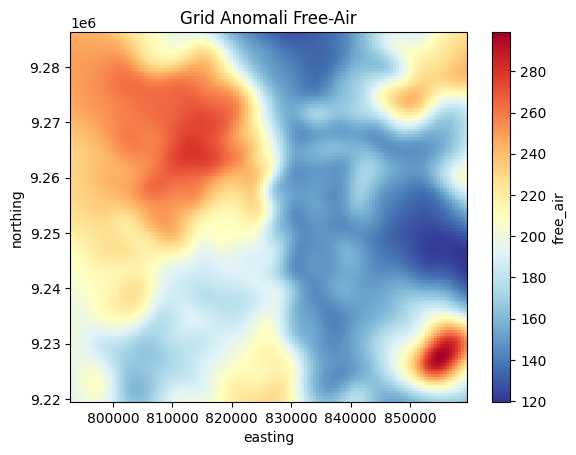

In [ ]:
import sys
import os

# Menampilkan jalur Python yang sedang digunakan oleh VS Code saat ini
print(f"Jalur Python: {sys.executable}")

try:
    import xarray as xr
    import harmonica as hm
    import pyproj
    import verde as vd
    print("✅ SEMUA LIBRARY TERDETEKSI: xarray, harmonica, pyproj, verde siap digunakan.")
except ImportError as e:
    print(f"❌ ERROR: {e}")
    print("Sedang mencoba sinkronisasi paksa...")
    # Perintah di bawah ini akan menginstal langsung ke jalur yang digunakan Notebook
    !{sys.executable} -m pip install xarray harmonica pyproj verde contextily

import pandas as pd
import numpy as np        # Wajib dijalankan
import verde as vd
import pyproj
import xarray as xr
import matplotlib.pyplot as plt

# 1. Load data
try:
    df = pd.read_csv("/content/tampomas_dg_potong.csv")
    print(f"Data berhasil dimuat: {len(df)} baris.")
except FileNotFoundError:
    print("Error: File CSV tidak ditemukan. Cek folder data/proses/")

# 2. Transformasi UTM
proj_utm = pyproj.Proj(proj="utm", zone=48, south=True, ellps="WGS84")
df['easting'], df['northing'] = proj_utm(df.longitude.values, df.latitude.values)

# 3. Gridding (Gunakan spacing agak besar dulu, misal 500m, agar TIDAK LOOP)
coords = (df.easting, df.northing)
reducer = vd.BlockReduce(np.median, spacing=500)
c_red, d_red = reducer.filter(coords, df.gravity_dist)

# 4. Fit Spline (Gunakan damping agar proses matematika lebih ringan bagi laptop)
spline = vd.Spline(damping=1e-4).fit(c_red, d_red)

# 5. Generate Grid
grid_fa = spline.grid(spacing=500, data_names="free_air")

# 6. Simpan Hasil
grid_fa.to_netcdf("/content/grid_tampomas_fa.nc")
print("✅ Gridding Berhasil!")

# 7. Plotting Sederhana
grid_fa.free_air.plot(cmap="RdYlBu_r")
plt.title("Grid Anomali Free-Air")
plt.show()

Jalur Python: /usr/bin/python3
✅ SEMUA LIBRARY TERDETEKSI: xarray, harmonica, pyproj, verde siap digunakan.


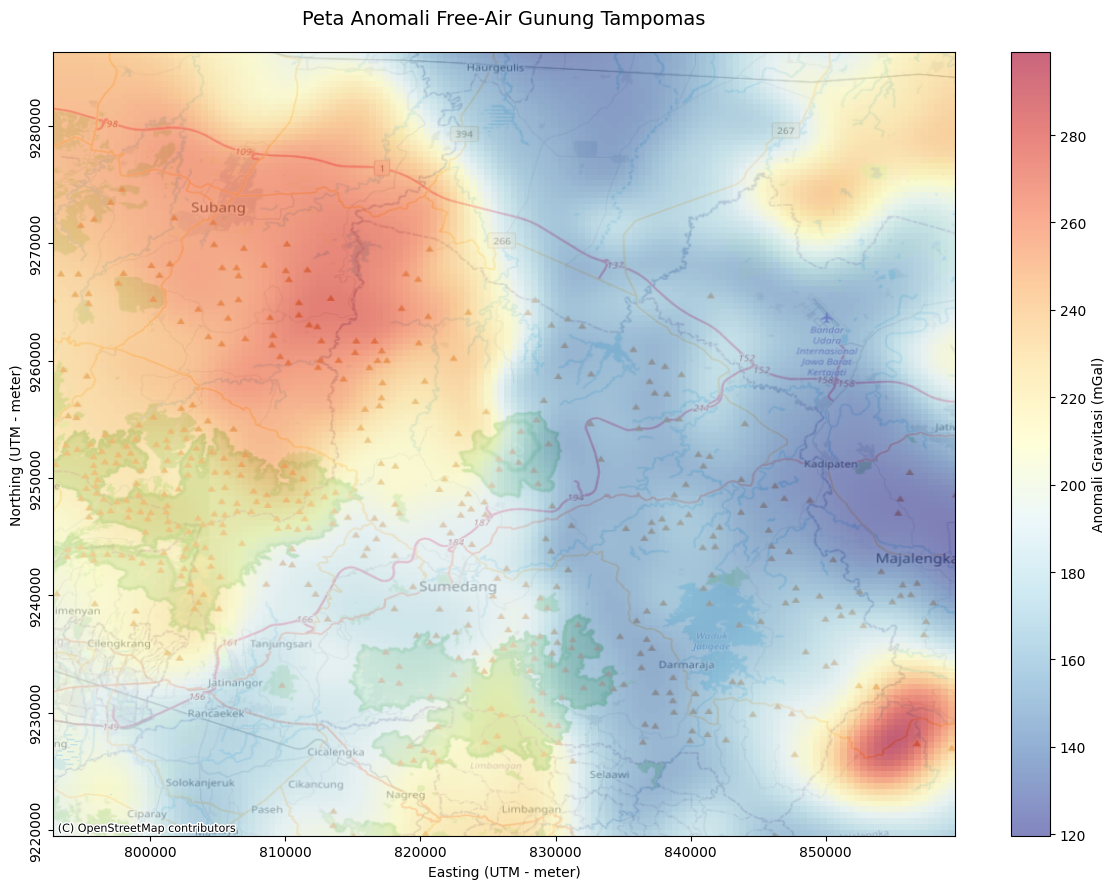

In [ ]:
import sys
import os

# Menampilkan jalur Python yang sedang digunakan oleh VS Code saat ini
print(f"Jalur Python: {sys.executable}")

try:
    import xarray as xr
    import harmonica as hm
    import pyproj
    import verde as vd
    print("✅ SEMUA LIBRARY TERDETEKSI: xarray, harmonica, pyproj, verde siap digunakan.")
except ImportError as e:
    print(f"❌ ERROR: {e}")
    print("Sedang mencoba sinkronisasi paksa...")
    # Perintah di bawah ini akan menginstal langsung ke jalur yang digunakan Notebook
    !{sys.executable} -m pip install xarray harmonica pyproj verde contextily

import xarray as xr
import matplotlib.pyplot as plt
import contextily as cx
import os

# 1. Pastikan Path Benar
path_file = "/content/grid_tampomas_fa.nc"

if not os.path.exists(path_file):
    print(f"❌ File TIDAK DITEMUKAN!")
else:
    grid = xr.open_dataset(path_file)
    var_name = list(grid.data_vars)[0]

    # 2. Plotting
    fig, ax = plt.subplots(figsize=(12, 9))

    # Plot data gravitasi dengan label satuan mGal pada colorbar
    # im = plot xarray
    im = grid[var_name].plot(
        ax=ax,
        cmap="RdYlBu_r",
        alpha=0.6,
        add_colorbar=True,
        cbar_kwargs={'label': 'Anomali Gravitasi (mGal)'} # Menambahkan satuan mGal
    )

    # 3. MENGATUR FORMAT ANGKA KOORDINAT (Plain / Bukan 1e6)
    ax.ticklabel_format(useOffset=False, style='plain')

    # 4. MENGATUR POSISI VERTIKAL PADA NORTHING
    # rotation=90 membuat angka berdiri tegak (vertikal)
    plt.yticks(rotation=90, va='center')

    # 5. Tambahkan Basemap (Satelit/OpenStreetMap)
    try:
        # Menggunakan EPSG:32748 (WGS 84 / UTM zone 48S) sesuai lokasi Jawa Barat
        cx.add_basemap(ax, crs="EPSG:32748", source=cx.providers.OpenStreetMap.Mapnik)
    except Exception as e:
        print(f"Gagal memuat basemap: {e}")

    # Labeling yang informatif
    plt.title("Peta Anomali Free-Air Gunung Tampomas", fontsize=14, pad=20)
    plt.xlabel("Easting (UTM - meter)", fontsize=10)
    plt.ylabel("Northing (UTM - meter)", fontsize=10)

    plt.tight_layout()
    plt.show()

Jalur Python: /usr/bin/python3
✅ SEMUA LIBRARY TERDETEKSI: xarray, harmonica, pyproj, verde siap digunakan.
Variabel yang terdeteksi di file: ['free_air']
Data 'height' tidak ada. Menggunakan asumsi 500m untuk demo.


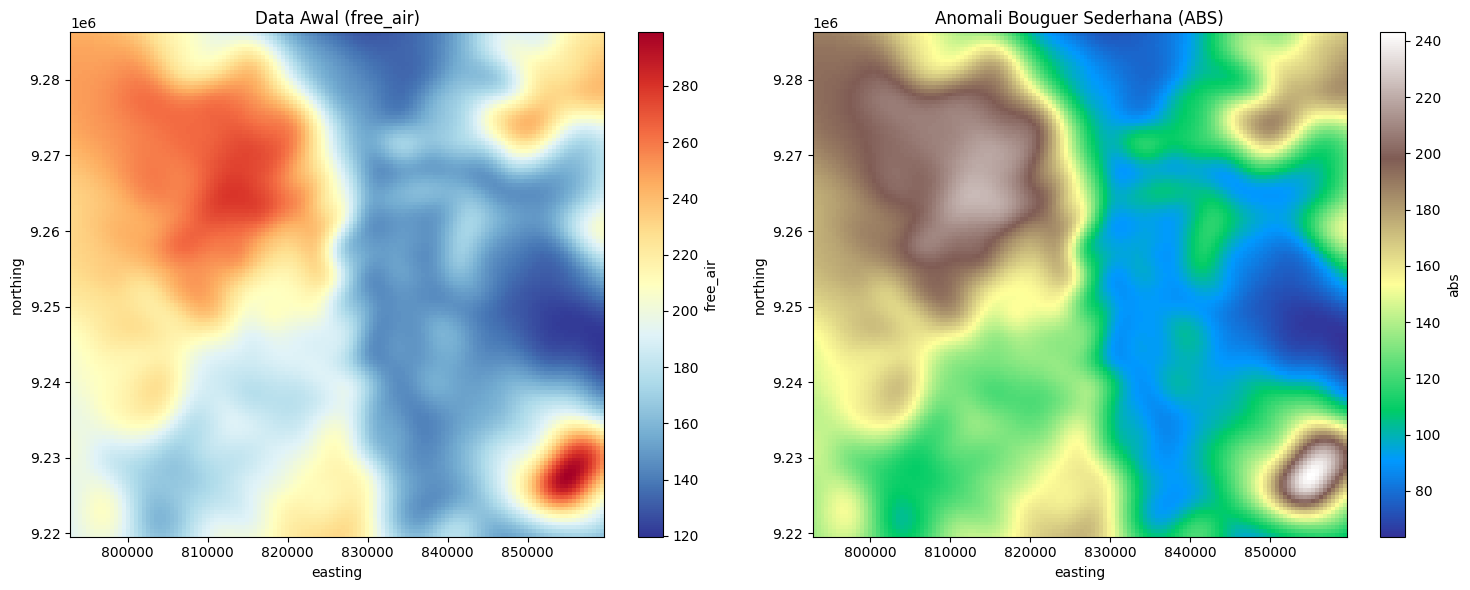

✅ BERHASIL! Peta ABS sudah muncul dan file disimpan.


In [ ]:
import sys
import os

# Menampilkan jalur Python yang sedang digunakan oleh VS Code saat ini
print(f"Jalur Python: {sys.executable}")

try:
    import xarray as xr
    import harmonica as hm
    import pyproj
    import verde as vd
    print("✅ SEMUA LIBRARY TERDETEKSI: xarray, harmonica, pyproj, verde siap digunakan.")
except ImportError as e:
    print(f"❌ ERROR: {e}")
    print("Sedang mencoba sinkronisasi paksa...")
    # Perintah di bawah ini akan menginstal langsung ke jalur yang digunakan Notebook
    !{sys.executable} -m pip install xarray harmonica pyproj verde contextily

import xarray as xr
import harmonica as hm
import matplotlib.pyplot as plt
import os

# 1. Load Grid yang tadi berhasil dibuat
path_grid = "/content/grid_tampomas_fa.nc"

if not os.path.exists(path_grid):
    print("File grid tidak ditemukan! Cek apakah tahap gridding benar-benar sukses.")
else:
    grid = xr.open_dataset(path_grid)

    # --- SOLUSI ERROR ATTRIBUTE ---
    # Mengecek apa nama variabel di dalam file secara otomatis
    var_list = list(grid.data_vars)
    print(f"Variabel yang terdeteksi di file: {var_list}")

    # Pilih variabel pertama (biasanya 'free_air' atau 'disturbance')
    data_key = var_list[0]
    # ------------------------------

    # 2. Parameter Fisika
    rho_kerak = 2670  # kg/m^3

    # 3. Data Elevasi (h)
    # Jika grid belum punya data height, kita pakai asumsi agar tidak error lagi
    if 'height' in grid.data_vars:
        h = grid.height
    else:
        print("Data 'height' tidak ada. Menggunakan asumsi 500m untuk demo.")
        h = 500

    # 4. Hitung Koreksi Bouguer Sederhana (CB)
    grid["bouguer_correction"] = 0.04193 * (rho_kerak / 1000) * h

    # 5. Hitung Anomali Bouguer Sederhana (ABS)
    # Menggunakan 'data_key' agar tidak terjadi AttributeError lagi
    grid["abs"] = grid[data_key] - grid.bouguer_correction

    # 6. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    grid[data_key].plot(ax=ax1, cmap="RdYlBu_r")
    ax1.set_title(f"Data Awal ({data_key})")

    grid.abs.plot(ax=ax2, cmap="terrain")
    ax2.set_title("Anomali Bouguer Sederhana (ABS)")

    plt.tight_layout()
    plt.show()

    # 7. Simpan Hasil Akhir
    grid.to_netcdf("/content/tampomas_abs_final.nc")
    print("✅ BERHASIL! Peta ABS sudah muncul dan file disimpan.")